In [1]:
from pathlib import Path
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

In [2]:
def load_all_metrics(
    dataset_name,
    sep_root="separation_metrics",
    social_root="social_metrics",
    fair_lloyd_root="fair_lloyd_metrics",
):
    results = {}

    # ------------------------------------------------
    # Separation Fair metrics
    # ------------------------------------------------
    sep_path = Path(sep_root) / f"metrics_{dataset_name}.npz"
    print(f"Looking for separation metrics at: {sep_path}")
    if sep_path.exists():
        data = np.load(sep_path, allow_pickle=True)

        results["separation"] = {
            "min_fair_dict": data["min_fair"].item(),
            "fairness_gaps": data["gap"].item(),
            "social_gap": data["social_gap"].item(),
            "kmeans_costs": data["cost"].item(),
            "max_fair_dict": data["max_fair"].item(),
        }
        #print(f"[Loaded] Separation metrics → {sep_path}")
    else:
        print("[Separation] No saved metrics found.")

    # ------------------------------------------------
    # Social Fair metrics
    # ------------------------------------------------
    social_path = Path(social_root) / \
                  f"social_metrics_{dataset_name}.npz"

    if social_path.exists():
        data = np.load(social_path, allow_pickle=True)

        results["social"] = {
            "max_fair_dict": data["max_fair_dict"].item(),
            "fairness_gaps": data["fairness_gaps"].item(),
            "sep_gap": data["sep_fairness_gaps"].item(), 
            "kmeans_costs": data["kmeans_costs"].item(),
            "unfair_kmeans_costs": data["unfair_kmeans_costs"].item(),
            "min_fair_dict": data["min_fair_dict"].item(),
            "lambda2_list": data["lambda2_list"],
            "seeds": data["seeds"],
        }
        print(f"[Loaded] Social metrics → {social_path}")
    else:
        print("[Social] No saved metrics found.")

    # ------------------------------------------------
    # Fair-Lloyd stats
    # ------------------------------------------------
    fair_lloyd_path = Path(fair_lloyd_root) / \
                      f"fair_lloyd_stats_{dataset_name}.npz"

    if fair_lloyd_path.exists():
        data = np.load(fair_lloyd_path)

        results["fair_lloyd"] = {
            "unfair_diff": data["unfair_diff"],
            "fair_diff": data["fair_diff"],
            "k_means_loss_unfair": data["k_means_loss_unfair"],
            "k_means_loss_fair": data["k_means_loss_fair"],
            "maxfair_unfair": data["maxfair_unfair"],
            "maxfair_fair": data["maxfair_fair"],
            "lambda2_list": data["lambda2_list"],
            "seeds": data["seeds"],
            "sep_min_fair": data["sep_min_fair"],
        }
        #print(f"[Loaded] Fair-Lloyd stats → {fair_lloyd_path}")
    else:
        print("[Fair-Lloyd] No saved stats found.")

    # ------------------------------------------------
    # Unified Metrics 
    # ------------------------------------------------
    weight_modes = ["balanced", "social_heavy", "separation_heavy"]

    results["unified"] = {}

    for mode in weight_modes:

        unified_path = Path("unified_metrics") / f"metrics_{dataset_name}_{mode}.npz"

        if unified_path.exists():

            data = np.load(unified_path, allow_pickle=True)

            results["unified"][mode] = {
                "lambda_values": data["lambda_values"],
                "kmeans_mean": data["kmeans_mean"],
                "kmeans_std": data["kmeans_std"],
                "social_mean": data["social_mean"],
                "social_std": data["social_std"],
                "separation_mean": data["separation_mean"],
                "separation_std": data["separation_std"],
                "objective_mean": data["objective_mean"],
                "objective_std": data["objective_std"],
                "social_gap_mean": data["social_gap_mean"],
                "social_gap_std": data["social_gap_std"],
                "sep_gap_mean": data["sep_gap_mean"],
                "sep_gap_std": data["sep_gap_std"],
            }

            #print(f"[Loaded] Unified metrics ({mode}) → {unified_path}")
    else:
        print("[Unified] No unified metrics found.")
    return results


In [3]:
def plot_multi_dataset_combined(
    dataset_results,       
    dataset_display_names, 
    lambda2_list,
    save_root="./plots",
):
    datasets = list(dataset_results.keys())
    n_datasets = len(datasets)

    n_rows = 3   
    n_cols = n_datasets

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.0 * n_datasets, 8),
        sharex=True
    )

    x_vals = np.arange(1, len(lambda2_list) + 1)

    def lam_label(l):
        return f"{l:.2f}".rstrip("0").rstrip(".")

    tick_labels = [lam_label(l) for l in lambda2_list]

    plt.style.use("seaborn-v0_8-whitegrid")

    for col, dataset_name in enumerate(datasets):

        sep_metrics, social_metrics, fair_lloyd_stats = dataset_results[dataset_name]

        def get_mean_std(d):
            means = [np.mean(d[l]) for l in lambda2_list]
            stds  = [np.std(d[l], ddof=1) for l in lambda2_list]
            return np.array(means), np.array(stds)

        sep_cost_mean, sep_cost_std = get_mean_std(sep_metrics["kmeans_costs"])
        soc_cost_mean, soc_cost_std = get_mean_std(social_metrics["kmeans_costs"])

        sep_min_mean, sep_min_std   = get_mean_std(sep_metrics["min_fair_dict"])
        soc_min_mean, soc_min_std   = get_mean_std(social_metrics["min_fair_dict"])

        sep_max_mean, sep_max_std   = get_mean_std(sep_metrics["max_fair_dict"])
        soc_max_mean, soc_max_std   = get_mean_std(social_metrics["max_fair_dict"])

        x_fair = len(lambda2_list) + 0.2  

        if fair_lloyd_stats is not None:
            
            km_fair     = fair_lloyd_stats["k_means_loss_fair"]
            max_fair    = fair_lloyd_stats["maxfair_fair"]
            sep_min_fair = fair_lloyd_stats.get("sep_min_fair", None)

                                  
            idx1 = len(lambda2_list) - 1     

            mu_fair_loss = np.nanmean(km_fair[idx1, :])
            sd_fair_loss = np.nanstd(km_fair[idx1, :], ddof=1)

            mu_fair_maxfair = np.nanmean(max_fair[idx1, :])
            sd_fair_maxfair = np.nanstd(max_fair[idx1, :], ddof=1)

            if sep_min_fair is not None:
                mu_sep_min_fair = np.nanmean(sep_min_fair[idx1, :])
                sd_sep_min_fair = np.nanstd(sep_min_fair[idx1, :], ddof=1)
        else:
            mu_fair_loss = sd_fair_loss = np.nan
            mu_fair_maxfair = sd_fair_maxfair = np.nan
            sep_min_fair = None

        
        ax0 = axes[0, col]

        ax0.errorbar(
            x_vals, sep_cost_mean, yerr=sep_cost_std,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            label="Separation fair k-means", color="C0"
        )
        ax0.errorbar(
            x_vals, soc_cost_mean, yerr=soc_cost_std,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            label="Social fair k-means", color="C1"
        )
        ax0.errorbar(
            x_fair, mu_fair_loss, yerr=sd_fair_loss,
            fmt="o", capsize=4, markersize=7,
            label="Fair-Lloyd", color="C2"
        )
        ax0.set_title(dataset_display_names.get(dataset_name, dataset_name),
                      fontsize=13)

        # ---------- Row 1: minimum separation cost ----------
        ax1 = axes[1, col]
        ax1.errorbar(
            x_vals, sep_min_mean, yerr=sep_min_std,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            color="C0"
        )
        ax1.errorbar(
            x_vals, soc_min_mean, yerr=soc_min_std,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            color="C1"
        )

        if fair_lloyd_stats is not None and sep_min_fair is not None:
            ax1.errorbar(
                x_fair, mu_sep_min_fair, yerr=sd_sep_min_fair,
                fmt="-o", capsize=4, markersize=7, color="C2"
            )

        # ---------- Row 2: maximum social cost ----------
        ax2 = axes[2, col]
        ax2.errorbar(
            x_vals, sep_max_mean, yerr=sep_max_std,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            color="C0"
        )
        ax2.errorbar(
            x_vals, soc_max_mean, yerr=soc_max_std,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            color="C1"
        )
        ax2.errorbar(
            x_fair, mu_fair_maxfair, yerr=sd_fair_maxfair,
            fmt="-o", capsize=4, markersize=7, color="C2"
        )

        
        ax2.set_xticks(x_vals)
        ax2.set_xticklabels(tick_labels)
        ax2.set_xlabel(r"$\lambda$", fontsize=11)

      
        for r in range(n_rows):
            axes[r, col].grid(alpha=0.4)
            axes[r, col].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

 
    axes[0, 0].set_ylabel("k-means cost", fontsize=12)
    axes[1, 0].set_ylabel("Separation fairness", fontsize=12)
    axes[2, 0].set_ylabel("Social cost", fontsize=12)

   
    legend_handles = [
        plt.Line2D([], [], color="C0", marker="o", linestyle="-",
                label="Separation fair k-means"),
        plt.Line2D([], [], color="C1", marker="o", linestyle="-",
                label="Social fair k-means"),
        plt.Line2D([], [], color="C2", marker="o", linestyle="-",
                label="Fair-Lloyd"),
    ]


    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,                 
        fontsize=11,
        frameon=True,
        facecolor="white",
        edgecolor="gray",
        bbox_to_anchor=(0.5, -0.03)   
    )
    plt.subplots_adjust(bottom=0.15)  
    plt.tight_layout()
    save_path = Path(save_root)
    save_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path / "cost_separation_social_across_datasets.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

Looking for separation metrics at: separation_metrics\metrics_adult.npz
[Loaded] Social metrics → social_metrics\social_metrics_adult.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_student.npz
[Loaded] Social metrics → social_metrics\social_metrics_student.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_bank.npz
[Loaded] Social metrics → social_metrics\social_metrics_bank.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_credit.npz
[Loaded] Social metrics → social_metrics\social_metrics_credit.npz
[Unified] No unified metrics found.


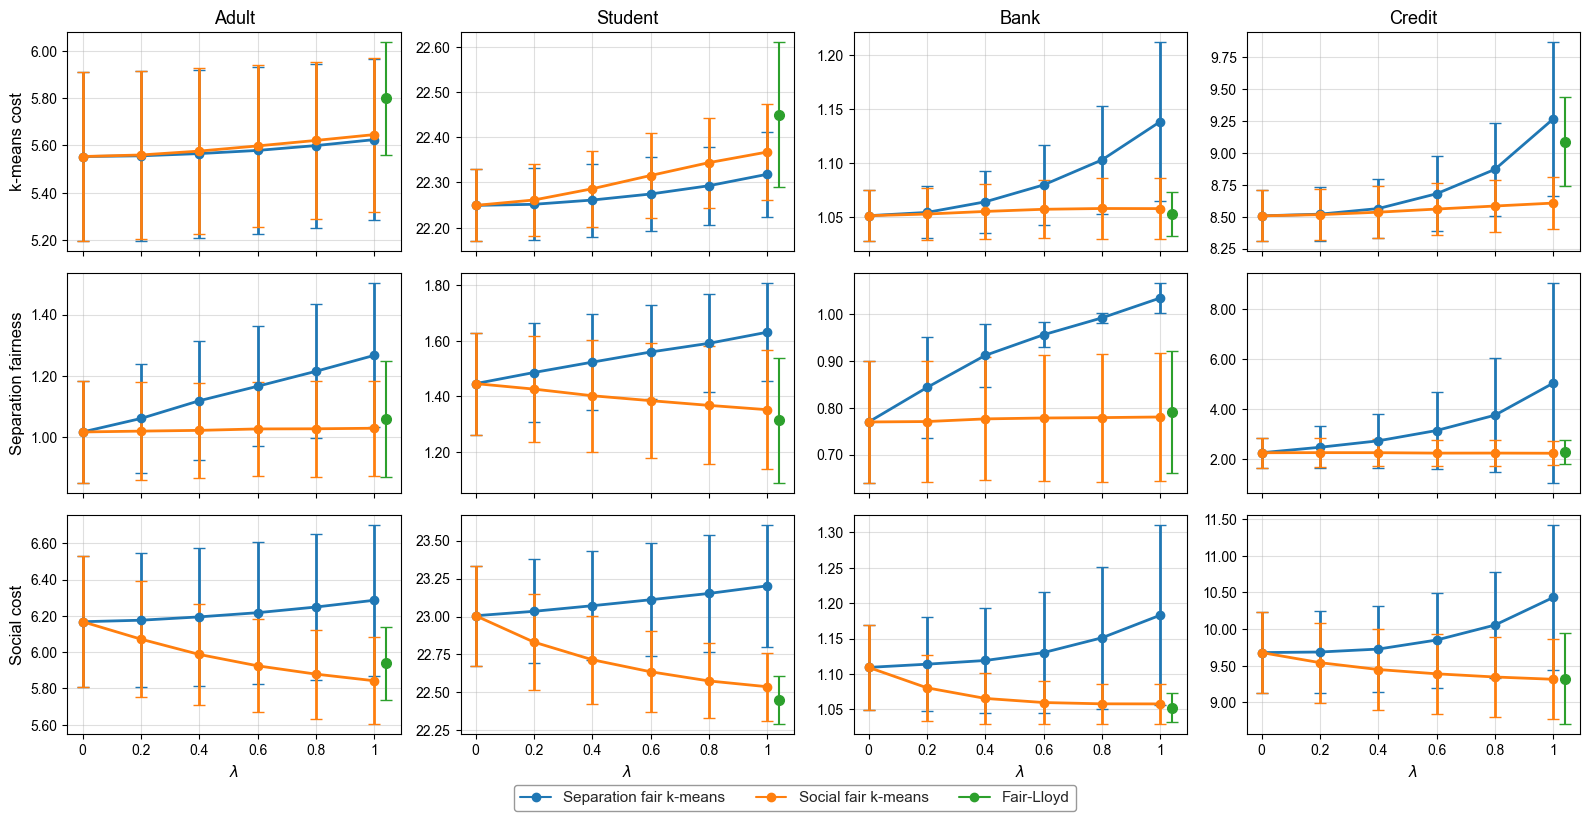

In [4]:
results = {}
lambda2_list = [0,0.2,0.4,0.6,0.8,1.0]

for name in ["adult", "student", "bank", "credit"]:
    loaded = load_all_metrics(name)
    results[name] = (
        loaded["separation"],
        loaded["social"],
        loaded["fair_lloyd"]
    )
dataset_display_names = {
    "adult": "Adult",
    "credit": "Credit",
    "bank": "Bank",
    "student": "Student",
}
plot_multi_dataset_combined(results, dataset_display_names, lambda2_list)


In [5]:
def plot_gap_comparison(dataset_names, lambda2_list, save_root="./plots"):
    """
    dataset_names: dict, e.g. {"adult": "Adult", "credit": "Credit", ...}
    lambda2_list: list of λ values, e.g. [0.0, 0.2, ..., 1.0]
    """

    plt.style.use("seaborn-v0_8-whitegrid")

    datasets = list(dataset_names.keys())
    n_datasets = len(datasets)
    n_rows = 2
    n_cols = n_datasets

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.0 * n_datasets, 6.5),
        sharex=True
    )
    if n_datasets == 1:
        axes = np.array(axes).reshape(n_rows, 1)

    x_vals = np.arange(1, len(lambda2_list) + 1)
    tick_labels = [f"{l:.2f}".rstrip("0").rstrip(".") for l in lambda2_list]

    for col, dataset in enumerate(datasets):
        display_name = dataset_names[dataset]
        metrics = load_all_metrics(dataset)

        # ---- separation-fair metrics ----
        sep_fair_dict = metrics["separation"]["fairness_gaps"]  
        soc_sep_dict = metrics["social"]["sep_gap"]
        

        # ---- social-fair metrics ----
        soc_social_dict = metrics["social"]["fairness_gaps"]    
                      
        sep_social_dict = metrics["separation"]["social_gap"]   
        
   
        def get_mean_std(d):
            means = [np.mean(d[l]) for l in lambda2_list]
            stds  = [np.std(d[l], ddof=1) for l in lambda2_list]
            return np.array(means), np.array(stds)
        
        def get_clipped_errors(means, stds):
            lower = np.minimum(stds, means)   
            upper = stds
            return [lower, upper]
        
        # --- Row 0: Separation fair k-means ---
        ax_top = axes[0, col]

        sep_fair_mean, sep_fair_std = get_mean_std(sep_fair_dict)
        sep_soc_mean,  sep_soc_std  = get_mean_std(sep_social_dict)

        

     
        ax_top.set_title(display_name, fontsize=13)

        # --- Row 1: Social fair k-means ---
        ax_bottom = axes[1, col]

        soc_social_mean, soc_social_std = get_mean_std(soc_social_dict)
        soc_sep_mean,    soc_sep_std    = get_mean_std(soc_sep_dict)

        yerr = get_clipped_errors(sep_fair_mean, sep_fair_std)
        ax_top.errorbar(
            x_vals, sep_fair_mean, yerr=yerr,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            label="Separation fairness gap", color="C0"
        )
        yerr = get_clipped_errors(soc_sep_mean, soc_sep_std)

        ax_top.errorbar(
            x_vals, soc_sep_mean, yerr=yerr,
            fmt="-s", capsize=4, linewidth=2, markersize=6,
            label="Social fairness gap", color="C1"
        )
        
        yerr = get_clipped_errors(soc_social_mean, soc_social_std)

        ax_bottom.errorbar(
            x_vals, soc_social_mean, yerr=yerr,
            fmt="-o", capsize=4, linewidth=2, markersize=6,
            label="Social fairness gap", color="C1"
        )
        yerr = get_clipped_errors(sep_soc_mean, sep_soc_std)

        ax_bottom.errorbar(
            x_vals, sep_soc_mean, yerr=yerr,
            fmt="-s", capsize=4, linewidth=2, markersize=6,
            label="Separation fairness gap", color="C0"
        )

      
        ax_bottom.set_xticks(x_vals)
        ax_bottom.set_xticklabels(tick_labels)
        ax_bottom.set_xlabel(r"$\lambda$", fontsize=11)

        
        for r in range(n_rows):
            axes[r, col].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
            axes[r, col].grid(alpha=0.4)

   
    axes[0, 0].set_ylabel("Separation fairness gap", fontsize=12)
    axes[1, 0].set_ylabel("Social fairness gap", fontsize=12)

    
    legend_handles = [
        plt.Line2D([], [], color="C0", marker="o", linestyle="-",
                label="Separation Fair k-means"),
        plt.Line2D([], [], color="C1", marker="s", linestyle="-",
                label="Social Fair k-means"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,                     
        fontsize=11,
        frameon=True,
        facecolor="white",
        edgecolor="gray",
        bbox_to_anchor=(0.5, -0.03)  
    )
     
    plt.subplots_adjust(bottom=0.18)  

    plt.tight_layout()
    Path(save_root).mkdir(parents=True, exist_ok=True)
    plt.savefig(Path(save_root) / "fairness_gap_comparison_across_datasets.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

Looking for separation metrics at: separation_metrics\metrics_adult.npz
[Loaded] Social metrics → social_metrics\social_metrics_adult.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_credit.npz
[Loaded] Social metrics → social_metrics\social_metrics_credit.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_bank.npz
[Loaded] Social metrics → social_metrics\social_metrics_bank.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_student.npz
[Loaded] Social metrics → social_metrics\social_metrics_student.npz
[Unified] No unified metrics found.


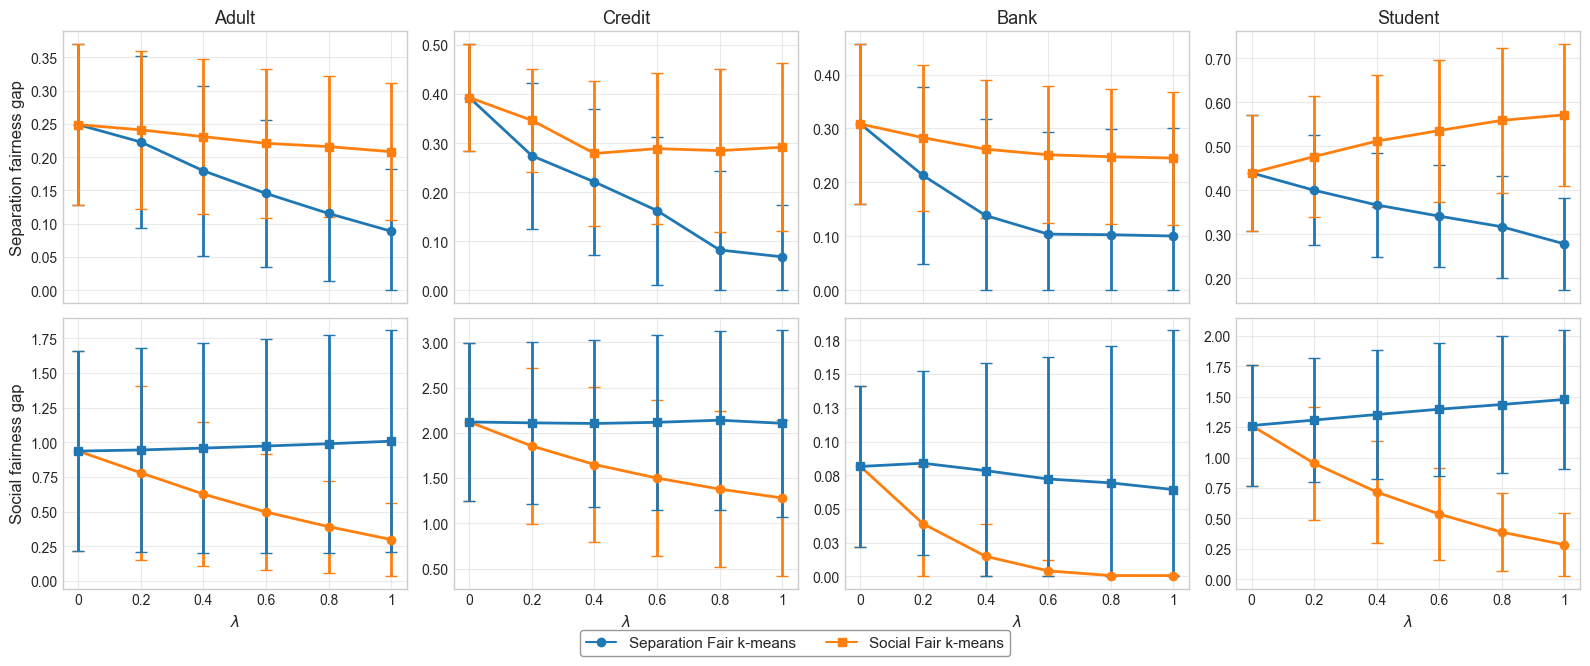

In [6]:
results = {}
lambda2_list = [0,0.2,0.4,0.6,0.8,1.0]

dataset_names = {
    "adult": "Adult",
    "credit": "Credit",
    "bank": "Bank",
    "student": "Student",
}
plot_gap_comparison(dataset_names, lambda2_list)


### Unified fairness plots

In [7]:
def plot_unified_metrics_across_datasets(
    dataset_results,
    dataset_display_names,
    save_root="./plots",
):

    datasets = list(dataset_results.keys())
    modes = ["balanced", "social_heavy", "separation_heavy"]
    mode_labels = {
        "balanced": r"$\alpha=\beta$",
        "social_heavy": r"$\alpha=3\lambda/4$",
        "separation_heavy": r"$\beta=3\lambda/4$"
    }

    colors = ["C0", "C1", "C2"]
    colors = {
    "kmeans": "C2",            
    "balanced": "C4",         
    "social_heavy": "C1",       
    "separation_heavy": "C0",  
    }
    n_datasets = len(datasets)

    plt.style.use("seaborn-v0_8-whitegrid")

    # ==========================================================
    # FIGURE 1: COSTS
    # ==========================================================
    fig1, axes = plt.subplots(3, n_datasets,
                              figsize=(4*n_datasets, 9),
                              sharex=False)

    for col, dataset_name in enumerate(datasets):

        unified = dataset_results[dataset_name]["unified"]

        
        ref = unified["balanced"]
        lam = ref["lambda_values"]

        # ---------------- Row 1: k-means ----------------
        ax = axes[0, col]

        for i, mode in enumerate(modes):
            data = unified[mode]
            ax.errorbar(
                lam,
                data["kmeans_mean"],
                yerr=data["kmeans_std"],
                fmt="-o",
                linewidth=2,
                markersize=6,
                capsize=4,
                color=colors[mode],
                label=mode_labels[mode]
            )

        ax.set_title(dataset_display_names.get(dataset_name, dataset_name))

        if col == 0:
            ax.set_ylabel("k-means cost")

        ax.grid(alpha=0.4)

        # ---------------- Row 2: separation ----------------
        ax = axes[1, col]

        for i, mode in enumerate(modes):

            data = unified[mode]

            ax.errorbar(
                lam,
                data["separation_mean"],
                yerr=data["separation_std"],
                fmt="-o",
                linewidth=2,
                markersize=6,
                capsize=4,
                color=colors[mode],
                label=mode_labels[mode]
            )

        if col == 0:
            ax.set_ylabel("Separation fairness")

        ax.grid(alpha=0.4)

        # ---------------- Row 3: social ----------------
        ax = axes[2, col]

        for i, mode in enumerate(modes):

            data = unified[mode]

            ax.errorbar(
                lam,
                data["social_mean"],
                yerr=data["social_std"],
                fmt="-o",
                linewidth=2,
                markersize=6,
                capsize=4,
                color=colors[mode],
                label=mode_labels[mode]
            )

        if col == 0:
            ax.set_ylabel("Social cost")

        ax.set_xlabel(r"$\lambda$")

        ax.grid(alpha=0.4)

    legend_handles = [
    plt.Line2D([], [], color=colors["balanced"], marker="o", linestyle="-",
               label=r"Balanced ($\lambda_{sep}=\lambda_{soc}$)"),

    plt.Line2D([], [], color=colors["separation_heavy"], marker="o", linestyle="-",
               label=r"Separation-heavy ($\lambda_{sep}=3\lambda/4$)"),

    plt.Line2D([], [], color=colors["social_heavy"], marker="o", linestyle="-",
               label=r"Social-heavy ($\lambda_{soc}=3\lambda/4$)")
    ]

    fig1.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        fontsize=11,
        frameon=True,
        facecolor="white",
        edgecolor="gray",
        bbox_to_anchor=(0.5, -0.03)
    )
    plt.tight_layout()

    Path(save_root).mkdir(parents=True, exist_ok=True)
    plt.savefig(Path(save_root) / "unified_costs_across_datasets.pdf",
                dpi=300, bbox_inches="tight")

    plt.show()

    # ==========================================================
    # FIGURE 2: GAPS
    # ==========================================================
    fig2, axes = plt.subplots(2, n_datasets,
                              figsize=(4*n_datasets, 6),
                              sharex=False)
    
    for col, dataset_name in enumerate(datasets):

        unified = dataset_results[dataset_name]["unified"]
        lam = unified["balanced"]["lambda_values"]

        # -------- Row 1: separation gap --------
        ax = axes[0, col]
        ax.set_title(dataset_display_names.get(dataset_name, dataset_name))
        for i, mode in enumerate(modes):

            data = unified[mode]
            y = data["sep_gap_mean"]
            std = data["sep_gap_std"]
            lower = np.minimum(std, y)  
            upper = std
           
            ax.errorbar(
                lam,
                y,
                yerr=[lower, upper],
                fmt="-o",
                linewidth=2,
                markersize=6,
                capsize=4,
                color=colors[mode],
                label=mode_labels[mode]
            )

        if col == 0:
            ax.set_ylabel("Separation fairness gap")

        ax.grid(alpha=0.4)

        # -------- Row 2: social gap --------
        ax = axes[1, col]

        for i, mode in enumerate(modes):
            data = unified[mode]
            
            y = data["social_gap_mean"]
            std = data["social_gap_std"]
            
            lower = np.minimum(std, y)
            upper = std
            ax.errorbar(
                lam,
                y,
                yerr=[lower, upper],
                fmt="-o",
                linewidth=2,
                markersize=6,
                capsize=4,
                color=colors[mode],
                label=mode_labels[mode]
            )

        if col == 0:
            ax.set_ylabel("Social fairness gap")

        ax.set_xlabel(r"$\lambda$")

        ax.grid(alpha=0.4)

    fig2.legend(handles=legend_handles, loc="lower center",
                ncol=3, fontsize=11, frameon=True,
                facecolor="white", edgecolor="gray",
                bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()

    plt.savefig(Path(save_root) / "unified_gaps_across_datasets.pdf",
                dpi=300, bbox_inches="tight")

    plt.show()

    print("[saved] unified plots")

Looking for separation metrics at: separation_metrics\metrics_adult.npz
[Loaded] Social metrics → social_metrics\social_metrics_adult.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_bank.npz
[Loaded] Social metrics → social_metrics\social_metrics_bank.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_credit.npz
[Loaded] Social metrics → social_metrics\social_metrics_credit.npz
[Unified] No unified metrics found.
Looking for separation metrics at: separation_metrics\metrics_student.npz
[Loaded] Social metrics → social_metrics\social_metrics_student.npz
[Unified] No unified metrics found.


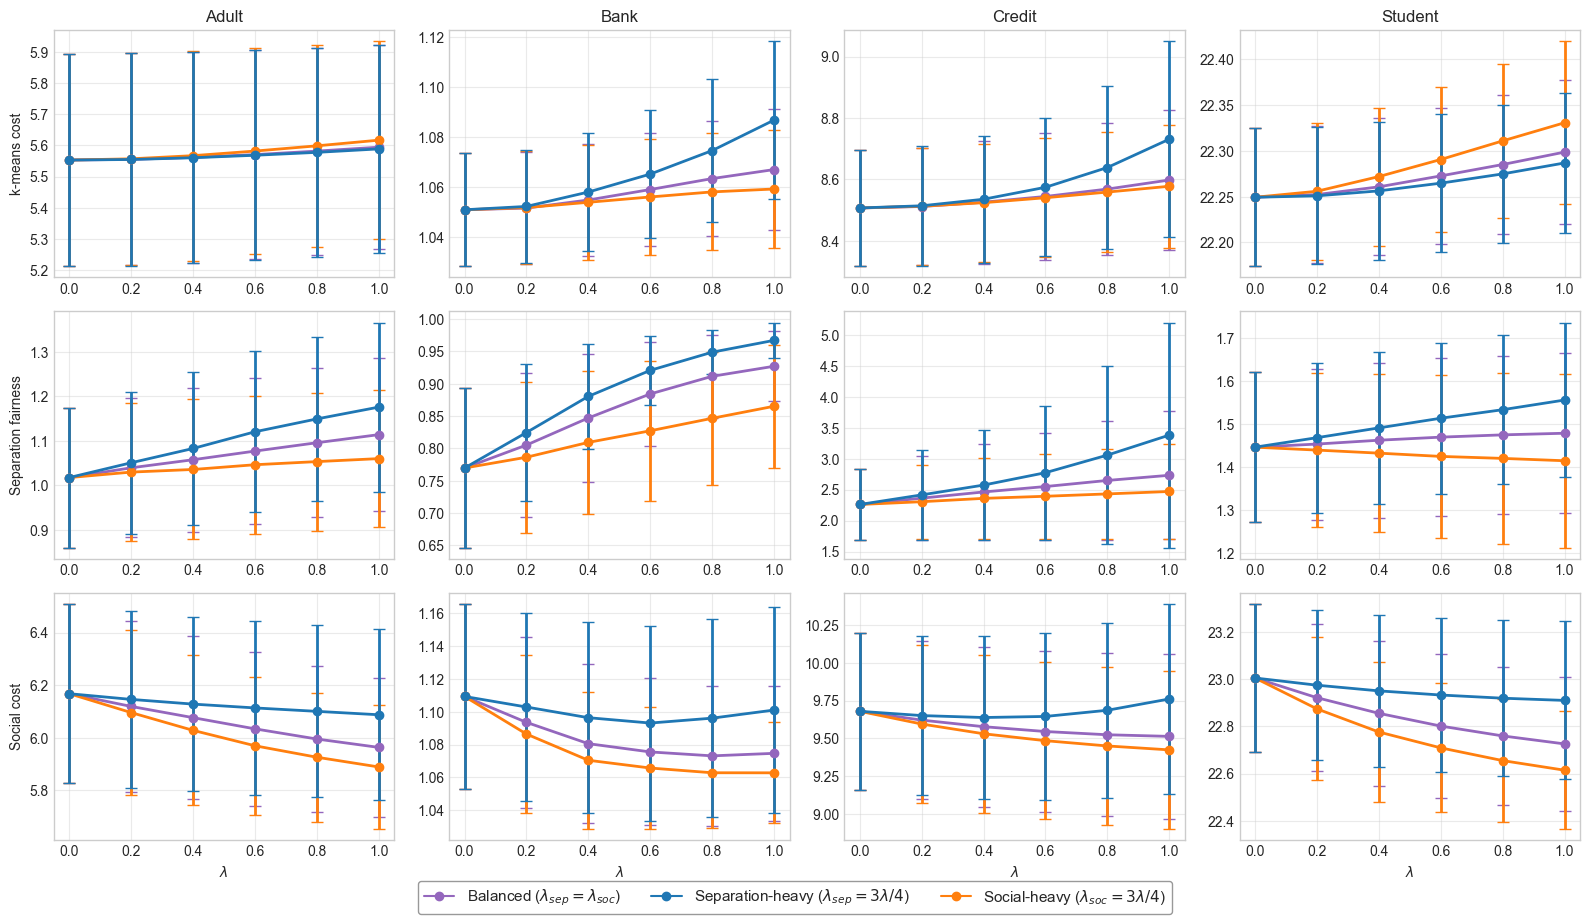

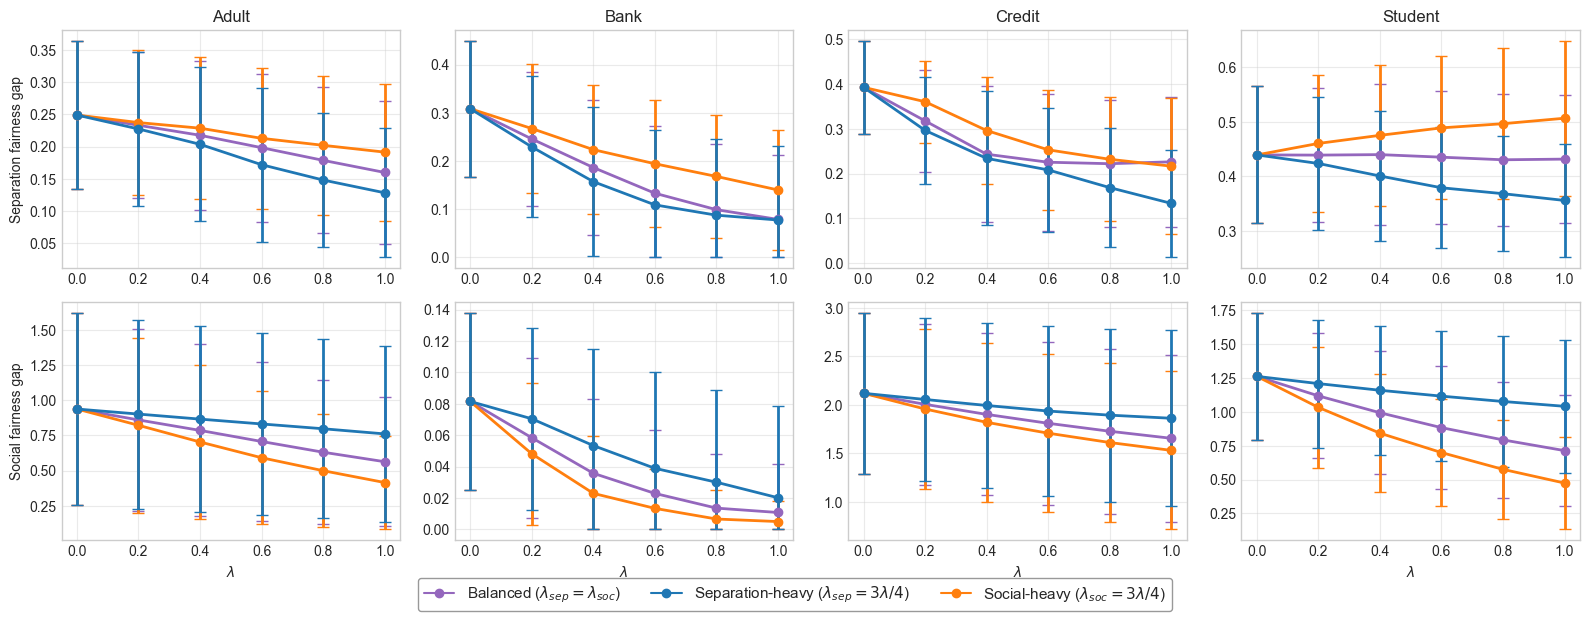

[saved] unified plots


In [8]:
results = {}
 

results = {
    ds: load_all_metrics(ds)
    for ds in ["adult", "bank", "credit", "student"]
}
dataset_display_names = {
    "adult": "Adult",
    "credit": "Credit",
    "bank": "Bank",
    "student": "Student",
}
plot_unified_metrics_across_datasets(results, dataset_display_names)
